# Instructions

(1) In mod08_sustainability_calculations, the energy usage is the product of the number of CPU cores, the number of runtime hours, and the number of kilowatts used per core. Update the function "compute_energy_kwh" to reflect this. _Hint_: You'll want to explore the data created in mod08_generate_emissions_data to learn the appropriate variable names.

(2) After you've updated (and saved) mod08_sustainability_calculations, run the cells in this notebook and answer the three discussion question. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from mod08_generate_emissions_data import generate_data
from mod08_sustainability_calculations import (
    compute_energy_kwh,
    compute_emissions,
    emissions_by_region,
    compute_total_runtime
)

c:\Users\samue\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### Get the data

In [2]:
jobs, carbon_intensity, power_per_core_kw, max_cores_per_region = generate_data()

### Inspect the Provided Data

In [3]:
print("Jobs Dataset:")
print(jobs)

print("\nCarbon Intensity by Region (kg CO2 per kWh):")
for region, intensity in carbon_intensity.items():
    print(f"{region}: {intensity}")

Jobs Dataset:
    job_id  cpu_cores  runtime_hours
0        1          1           0.50
1        2          2           1.20
2        3          4           0.75
3        4          8           2.50
4        5          2           1.00
5        6          1           0.30
6        7         16           3.00
7        8          4           1.50
8        9          8           2.00
9       10          2           0.80
10      11          4           0.50
11      12          8           2.25
12      13          2           1.60
13      14          8           0.90
14      15         16           1.10

Carbon Intensity by Region (kg CO2 per kWh):
coal_heavy_region: 0.9
renewable_region: 0.05


### Compute Energy Usage

In [4]:
jobs_with_energy = compute_energy_kwh(jobs, power_per_core_kw)

print("Jobs with Energy Computed:")
print(jobs_with_energy)

total_energy = jobs_with_energy["energy_kwh"].sum()
print(f"\nTotal Energy Consumption: {total_energy:.4f} kWh")

Jobs with Energy Computed:
    job_id  cpu_cores  runtime_hours  energy_kwh
0        1          1           0.50       0.025
1        2          2           1.20       0.120
2        3          4           0.75       0.150
3        4          8           2.50       1.000
4        5          2           1.00       0.100
5        6          1           0.30       0.015
6        7         16           3.00       2.400
7        8          4           1.50       0.300
8        9          8           2.00       0.800
9       10          2           0.80       0.080
10      11          4           0.50       0.100
11      12          8           2.25       0.900
12      13          2           1.60       0.160
13      14          8           0.90       0.360
14      15         16           1.10       0.880

Total Energy Consumption: 7.3900 kWh


### Compute Emissions for Each Region

In [5]:
region_emissions = emissions_by_region(jobs_with_energy, carbon_intensity)

print("Total Emissions by Region (kg CO2):")
for region, emissions in region_emissions.items():
    print(f"{region}: {emissions:.4f}")

Total Emissions by Region (kg CO2):
coal_heavy_region: 6.6510
renewable_region: 0.3695


### Visualize Emissions by Region

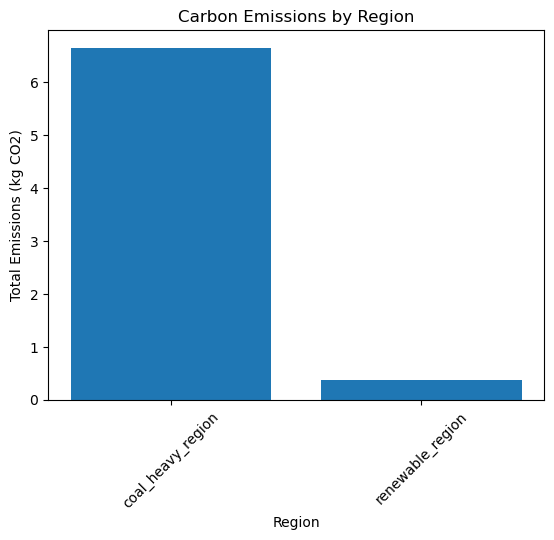

In [6]:
plt.figure()
plt.bar(region_emissions.keys(), region_emissions.values())
plt.xlabel("Region")
plt.ylabel("Total Emissions (kg CO2)")
plt.title("Carbon Emissions by Region")
plt.xticks(rotation=45)
plt.show()

### Scenario 1: All Jobs in Coal-Heavy Region

In [23]:
coal_region = max(carbon_intensity, key=carbon_intensity.get)
all_coal_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[coal_region]
)

all_coal_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[coal_region])

print(f"All jobs in {coal_region}: {all_coal_emissions:.4f} kg CO2, Runtime: {all_coal_runtime:.2f} h")

All jobs in coal_heavy_region: 6.6510 kg CO2, Runtime: 7.10 h


### Scenario 2: All Jobs in Renewable Region

In [8]:
renewable_region = min(carbon_intensity, key=carbon_intensity.get)
all_renewable_emissions = compute_emissions(
    jobs_with_energy,
    carbon_intensity[renewable_region]
)

all_renewable_runtime = compute_total_runtime(jobs_with_energy, max_cores_per_region[renewable_region])

print(f"All jobs in {renewable_region}: {all_renewable_emissions:.4f} kg CO2, Runtime: {all_renewable_runtime:.2f} h")

All jobs in renewable_region: 0.3695 kg CO2, Runtime: 11.95 h


### Scenario 3: Assign High CPU Jobs to Renewable Region

In [9]:
# Decide which jobs to assign to renewable region
median = jobs_with_energy["cpu_cores"].median()

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= median]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < median]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 0.7945 kg CO2, Runtime: 10.35 h


### Strategy Comparison Plot

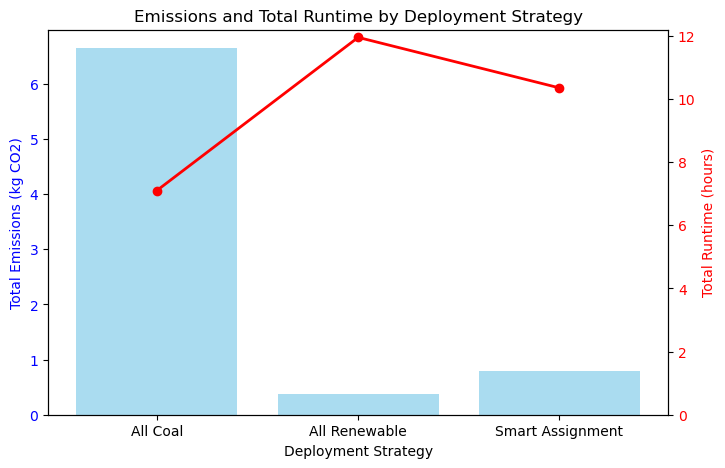

In [10]:
# Prepare data
strategy_names = ["All Coal", "All Renewable", "Smart Assignment"]
emission_values = [all_coal_emissions, all_renewable_emissions, smart_emissions]
runtime_values = [all_coal_runtime, all_renewable_runtime, smart_runtime]

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for emissions
ax1.bar(strategy_names, emission_values, color='skyblue', alpha=0.7)
ax1.set_ylabel("Total Emissions (kg CO2)", color='blue')
ax1.set_xlabel("Deployment Strategy")
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Emissions and Total Runtime by Deployment Strategy")

# Line chart for runtime
ax2 = ax1.twinx()
ax2.plot(strategy_names, runtime_values, color='red', marker='o', linewidth=2)
ax2.set_ylabel("Total Runtime (hours)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(bottom=0)

plt.show()

# Discussion Questions

### Similar to what we did in Scenario 3, let's look at different quantile values to decide what proportion of jobs to assign to renewable energy.

In [33]:
# Decide which jobs to assign to renewable region
cpu_threshold = jobs_with_energy["cpu_cores"].quantile(
    # enter a choice between 0 and 1 here
    .75
)

green_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] >= cpu_threshold]
dirty_jobs = jobs_with_energy[jobs_with_energy["cpu_cores"] < cpu_threshold]

# compute the new total emissions
smart_emissions = compute_emissions(green_jobs, carbon_intensity[renewable_region]) + \
                  compute_emissions(dirty_jobs, carbon_intensity[coal_region])

# compute the new total runtime (with parallelization)
smart_runtime = max(compute_total_runtime(green_jobs, max_cores_per_region[renewable_region]),
                    compute_total_runtime(dirty_jobs, max_cores_per_region[coal_region]))

print(f"High-CPU jobs to {renewable_region}: {smart_emissions:.4f} kg CO2, Runtime: {smart_runtime:.2f} h")

High-CPU jobs to renewable_region: 1.2620 kg CO2, Runtime: 8.85 h


### Comment on what you believe is the most appropriate threshold given the tradeoff between emissions and runtime.

If we set our CPU threshold to .75 (Q3) or in other words allocate only the top 25% most intensive jobs to the renewable region. We could cut emissions to less than a fifth of what they would be while still maintaining a competitive total run time of 8.85 hours (7.1 hrs if all in coal). I'm of the opinion that eventually we will should switch to all renewable, but I think this is a much more digestable trade off for most people. The added benefit of having the additional cores of the renewable region off sets some of the inefficiency of that region. Infact you could actually reduce runtime by only allocating the max & still reduce emissions to half. Though I would hesitate to say this scales though, if we have many high core jobs it is possible it still result in more time in the long run. Still though in most cases even just a small assignment to the most intensive jobs could result in a comparable or even better run time with dramatically less emissions.

### In this notebook, we calculate emissions and runtimes as the inputs of our cost-benefit analysis. Name and explain at least one other cost or benefit that is not considered here.

The most obvious one to me is Price. It is such a driving motivator in real life. Even if Renewable Energy is less efficient if it's cheaper it could be a more attractive option, conversely even if emissions are worsened by coal energy if that's cheaper people will want to use coal.

### List at least two different stakeholders that would be affected by a strategic decision regarding the assignment of resources explored in this notebook. In your opinion, which stakeholder's interests are most compelling?

1. One Stakeholder could be investors into your company. While not a garuntee increased efficiency likely has at least some correlation with profits. Alternatively could be coal energy companies that certainly benefit financially from any investment into their industry.
2. Another Stakeholder could be Climate Activist Organizations or Maybe local communities where the coal mining takes place where the incentive would be to keep emissions as low as possible to protect the environment or to maintain the environment of the local communities. The local community specifically is a little more nuanced as it's possible the economic boon of the mining in this area could off set the environmental degredation to a lot of people, but I still think overall these groups would want lower emissions, especially if they weren't already an established mining town.

Personally I think stakeholders who prioritize the lowering of emissions are generally more noble. I think a stakeholder who prioritizes the efficiency/raising of emissions is generally doing it because it benefits them or those immediately around them and is turning a blind eye to the fact that it is almost assuredly screwing more people over in the long term by messing up the environment. The foresight to make a decisions that help the majority in the long term, even if they may hurt in the short term, is a very important trait that I think should be more sought after and prioritized.